In [1]:
import pandas as pd

# Load the two raw CSVs
fake_df = pd.read_csv("data/Fake.csv")
real_df = pd.read_csv("data/True.csv")

# Assign labels: 0 = fake, 1 = real
# We do this BEFORE combining, while it's unambiguous which file is which
fake_df["label"] = 0
real_df["label"] = 1

# Combine into a single dataframe
df = pd.concat([fake_df, real_df], axis=0, ignore_index=True)

# Shuffle rows so fake/real aren't grouped together
# frac=1 means "sample 100% of rows" i.e. shuffle everything
# reset_index gives clean sequential indices after shuffling
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Quick look
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64
label
0    52.298543
1    47.701457
Name: proportion, dtype: float64

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Text length stats (word count):
count    44898.000000
mean       405.282284
std        351.265595
min          0.000000
25%        203.000000
50%        362.000000
75%        513.000000
max       8135.000000
Name: text_length, dtype: float64


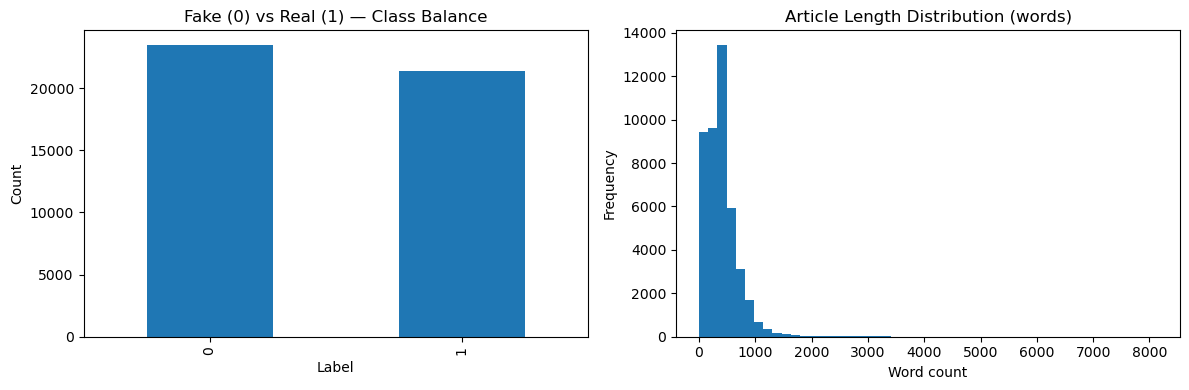

In [2]:
# 1. Class balance — how many fake vs real articles
print("Class distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True) * 100)  # as percentages

# 2. Missing values — check every column, not just 'text'
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Text length distribution
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

print("\nText length stats (word count):")
print(df["text_length"].describe())

# 4. Visualize class balance and text length
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["label"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Fake (0) vs Real (1) — Class Balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

df["text_length"].plot(kind="hist", bins=50, ax=axes[1])
axes[1].set_title("Article Length Distribution (words)")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X = df["text"]        # feature: raw article text
y = df["label"]       # target: 0 = fake, 1 = real

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y            # preserve fake/real ratio in both splits
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train size: 35918
Test size: 8980

Train label distribution:
label
0    0.522997
1    0.477003
Name: proportion, dtype: float64

Test label distribution:
label
0    0.52294
1    0.47706
Name: proportion, dtype: float64


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# stop_words='english' removes common filler words (the, is, and, ...)
#   that carry little distinguishing signal
# max_df=0.7 ignores words that appear in more than 70% of documents
#   (too common to be useful, similar spirit to stop words but data-driven)
tfidf = TfidfVectorizer(stop_words="english", max_df=0.7)

# fit_transform on TRAIN ONLY:
#   "fit" = learn the vocabulary + IDF weights from training data
#   "transform" = convert text into TF-IDF vectors using what was learned
X_train_tfidf = tfidf.fit_transform(X_train)

# transform (NOT fit_transform) on TEST:
#   we reuse the vocabulary/weights learned from train,
#   we do NOT let the vectorizer learn anything new from test data
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (35918, 111073)
Test TF-IDF shape: (8980, 111073)


In [5]:
from sklearn.linear_model import PassiveAggressiveClassifier

# max_iter: max number of passes over the training data
# random_state: reproducibility, same reasoning as before
pac = PassiveAggressiveClassifier(max_iter=50, random_state=42)

# .fit() is where the actual learning happens:
# the model looks at X_train_tfidf (features) and y_train (true labels),
# and adjusts its internal weights via the passive-aggressive update rule
pac.fit(X_train_tfidf, y_train)

print("Model trained.")
print("Number of features model learned weights for:", pac.coef_.shape[1])

Model trained.
Number of features model learned weights for: 111073


Accuracy: 0.9935  (99.35%)
F1 Score: 0.9932

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4696
        Real       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



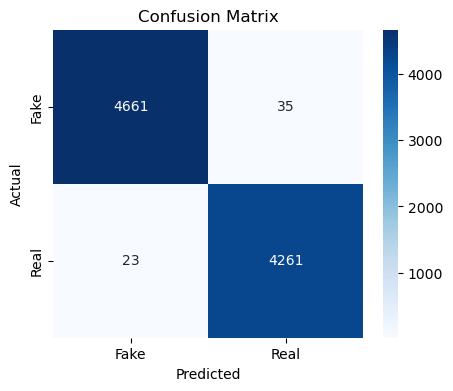

In [6]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the held-out test set
y_pred = pac.predict(X_test_tfidf)

# Core metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print(f"F1 Score: {f1:.4f}")

# Full precision/recall/f1 breakdown per class — useful detail for interviews
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

# Confusion matrix — shows exactly where the model gets confused
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:
import joblib
import os

# Create a folder to keep saved artifacts organized
os.makedirs("model", exist_ok=True)

# Save the trained classifier
joblib.dump(pac, "model/fake_news_model.pkl")

# Save the fitted vectorizer — SEPARATELY, but into the same folder
# so it's obvious at a glance that these two files belong together
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

print("Model and vectorizer saved to /model")

Model and vectorizer saved to /model


In [8]:
import os
print(os.getcwd())

C:\Users\Lenovo\fake-news-detector
